# B — Diurnal Profiles: 24-hour Temperature Cycles
Mean ± 1 std band across all grid cells for each area/date combination.
Shows how temperature evolves through the day and identifies peak hours.

**Saves to** `../figures/B_diurnal_profiles/`

In [1]:
import sys
from pathlib import Path
NB_DIR = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
sys.path.insert(0, str(NB_DIR))
from config import *

SAVE_DIR = FIGURES_DIR / 'B_diurnal_profiles'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print('Setup done. Saving to:', SAVE_DIR)

Config loaded.  ROOT=/home/mourouzidou/Downloads/Anastasia
Output dir : /home/mourouzidou/Downloads/Anastasia/output
Figures dir: /home/mourouzidou/Downloads/Anastasia/figures
Setup done. Saving to: /home/mourouzidou/Downloads/Anastasia/figures/B_diurnal_profiles


In [2]:
print('Loading atmosphere...'); atm_raw = load_csvs('atmosphere')
print('Loading surface...');    srf_raw = load_csvs('surface')
SURF_TEMP_COL, SURF_ALB_COL = detect_surface_cols(srf_raw)
print(f'Surface temp col: {SURF_TEMP_COL}')
atm = atm_raw[atm_raw[BUILDING_COL] == 0].copy() if BUILDING_COL in atm_raw.columns else atm_raw.copy()
srf = srf_raw.copy()
print(f'atm outdoor rows: {len(atm):,}  |  srf rows: {len(srf):,}')

Loading atmosphere...
  Shaded_15Aug_atmosphere.parquet  →  260,000 rows
  Shaded_15Feb_atmosphere.parquet  →  260,000 rows
  Shaded_15Nov_atmosphere.parquet  →  510,000 rows
  Shaded_31Mar_atmosphere.parquet  →  260,000 rows
  Waterfront_15Aug_atmosphere.parquet  →  260,000 rows
  Waterfront_15Feb_atmosphere.parquet  →  260,000 rows
  Waterfront_15Nov_atmosphere.parquet  →  260,000 rows
  Waterfront_31Mar_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Aug_atmosphere.parquet  →  300,000 rows
  Zefkseidos_15Feb_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Nov_atmosphere.parquet  →  260,000 rows
  Zefkseidos_31Mar_atmosphere.parquet  →  260,000 rows
Loading surface...
  Shaded_15Aug_surface.parquet  →  250,000 rows
  Shaded_15Feb_surface.parquet  →  250,000 rows
  Shaded_15Nov_surface.parquet  →  250,000 rows
  Shaded_31Mar_surface.parquet  →  250,000 rows
  Waterfront_15Aug_surface.parquet  →  250,000 rows
  Waterfront_15Feb_surface.parquet  →  250,000 rows
  Waterfront_15Nov_

## B1 — Air temperature diurnal profiles (one panel per area)

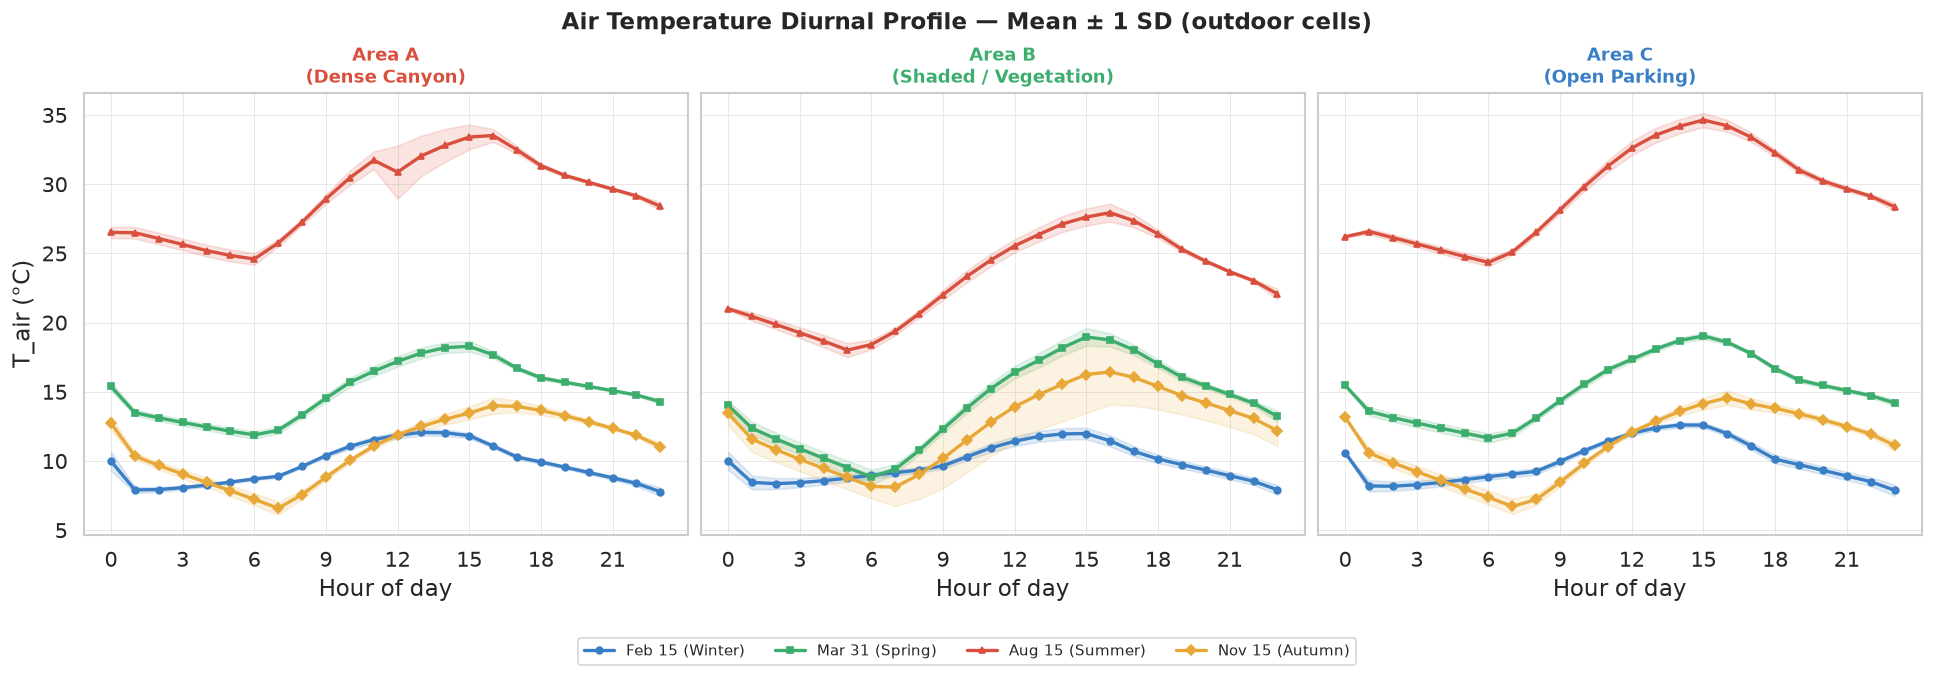

Saved B1


In [3]:
hours = sorted(atm['hour'].dropna().unique())

fig, axes = plt.subplots(1, len(AREA_ORDER), figsize=(16, 5), sharey=True, constrained_layout=True)
fig.suptitle('Air Temperature Diurnal Profile — Mean ± 1 SD (outdoor cells)', fontsize=14, fontweight='bold')

for ax, area in zip(axes, AREA_ORDER):
    ax.set_title(AREA_LABELS[area], fontsize=11, fontweight='bold', color=AREA_COLORS[area])
    ax.set_xlabel('Hour of day')
    if area == AREA_ORDER[0]: ax.set_ylabel('T_air (°C)')
    for date in DATE_ORDER:
        sub = atm[(atm['area'] == area) & (atm['date'] == date)]
        if len(sub) == 0: continue
        grp = sub.groupby('hour')[AIR_TEMP_COL]
        mn  = grp.mean().reindex(hours)
        sd  = grp.std().reindex(hours)
        color = DATE_COLORS[date]
        ax.plot(hours, mn, color=color, lw=2, marker=DATE_MARKERS[date], ms=4, label=DATE_LABELS[date])
        ax.fill_between(hours, mn - sd, mn + sd, color=color, alpha=0.15)
    ax.set_xticks(range(0, 24, 3))
    ax.grid(lw=0.5, alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=True)
fig.savefig(SAVE_DIR / 'B1_air_diurnal_by_area.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved B1')

## B2 — Surface temperature diurnal profiles (one panel per area)

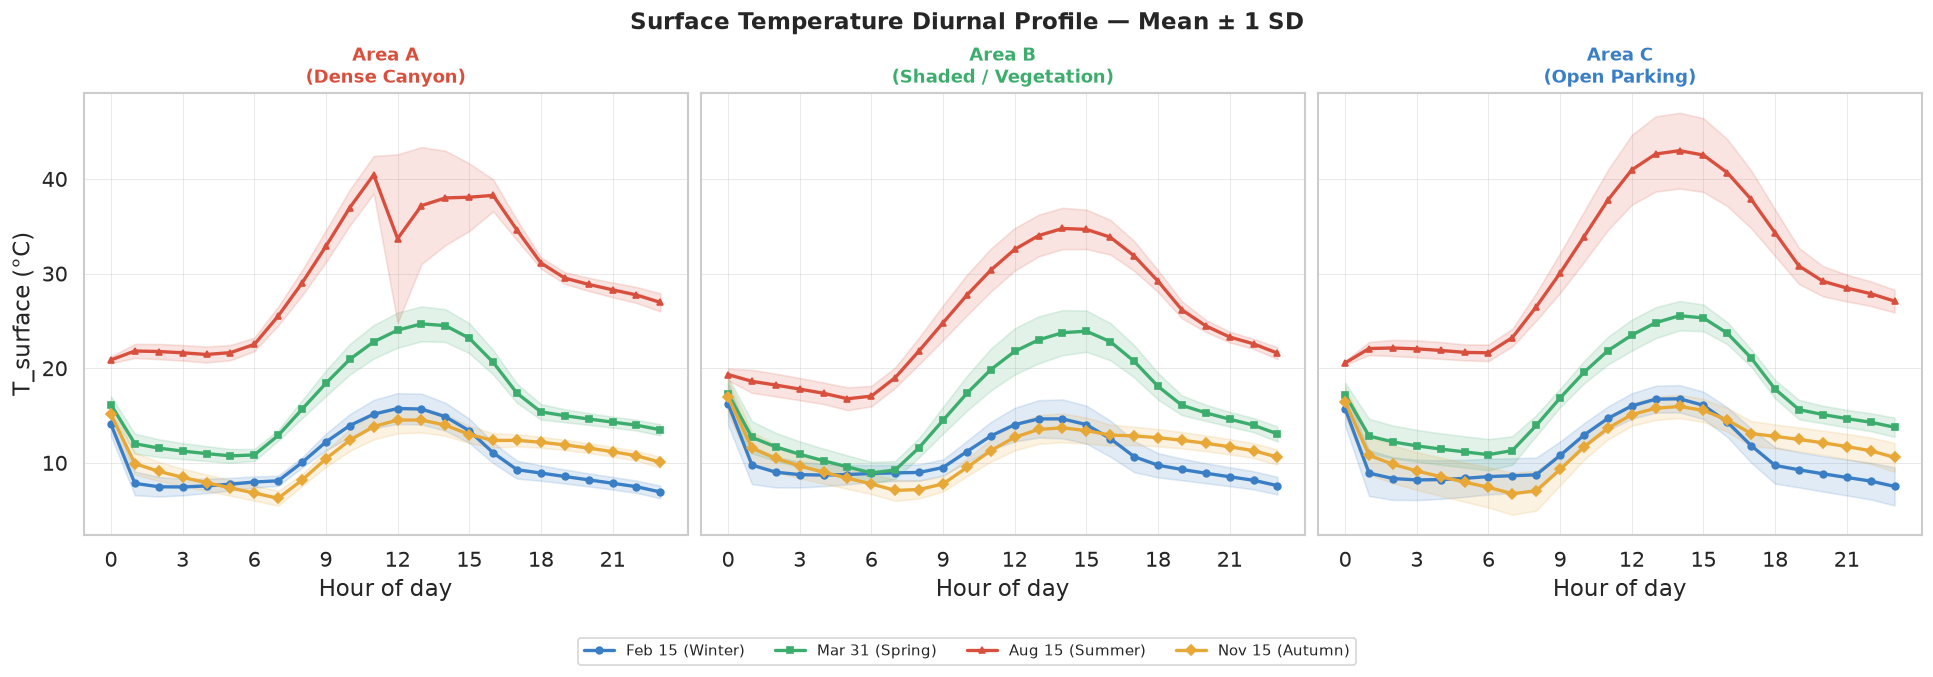

Saved B2


In [4]:
hours_s = sorted(srf['hour'].dropna().unique())

fig, axes = plt.subplots(1, len(AREA_ORDER), figsize=(16, 5), sharey=True, constrained_layout=True)
fig.suptitle('Surface Temperature Diurnal Profile — Mean ± 1 SD', fontsize=14, fontweight='bold')

for ax, area in zip(axes, AREA_ORDER):
    ax.set_title(AREA_LABELS[area], fontsize=11, fontweight='bold', color=AREA_COLORS[area])
    ax.set_xlabel('Hour of day')
    if area == AREA_ORDER[0]: ax.set_ylabel('T_surface (°C)')
    for date in DATE_ORDER:
        sub = srf[(srf['area'] == area) & (srf['date'] == date)]
        if len(sub) == 0: continue
        grp = sub.groupby('hour')[SURF_TEMP_COL]
        mn  = grp.mean().reindex(hours_s)
        sd  = grp.std().reindex(hours_s)
        color = DATE_COLORS[date]
        ax.plot(hours_s, mn, color=color, lw=2, marker=DATE_MARKERS[date], ms=4, label=DATE_LABELS[date])
        ax.fill_between(hours_s, mn - sd, mn + sd, color=color, alpha=0.15)
    ax.set_xticks(range(0, 24, 3))
    ax.grid(lw=0.5, alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), frameon=True)
fig.savefig(SAVE_DIR / 'B2_surface_diurnal_by_area.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved B2')

## B3 — All areas overlaid: summer day (15Aug)

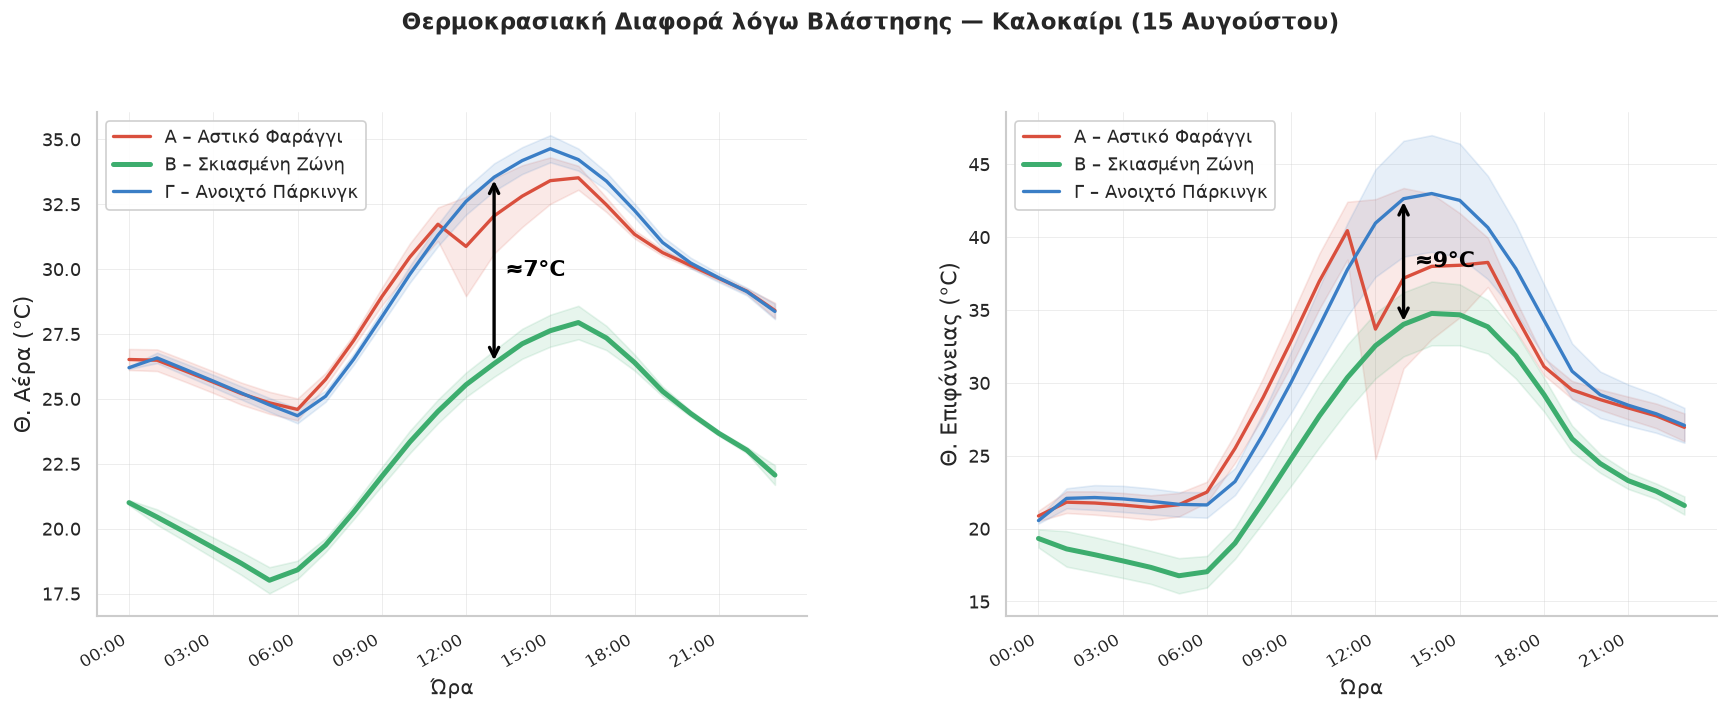

Saved B3


In [5]:
GR_AREA_SHORT = {
    'Zefkseidos': 'Α – Αστικό Φαράγγι',
    'Shaded':     'Β – Σκιασμένη Ζώνη',
    'Waterfront': 'Γ – Ανοιχτό Πάρκινγκ',
}

# Pre-compute hourly mean/sd for each area, summer only
def summer_stats(df, col):
    out = {}
    for area in AREA_ORDER:
        sub = df[(df['area'] == area) & (df['date'] == '15Aug')]
        if not len(sub): continue
        grp = sub.groupby('hour')[col]
        hrs = np.array(sorted(sub['hour'].unique()))
        out[area] = (hrs, grp.mean().reindex(hrs), grp.std().reindex(hrs))
    return out

atm_stats = summer_stats(atm, AIR_TEMP_COL)
srf_stats = summer_stats(srf, SURF_TEMP_COL)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.subplots_adjust(left=0.07, right=0.97, top=0.84, bottom=0.14, wspace=0.28)
fig.suptitle('Θερμοκρασιακή Διαφορά λόγω Βλάστησης — Καλοκαίρι (15 Αυγούστου)',
             fontsize=14, fontweight='bold')

panels = [
    (atm_stats, 'Θ. Αέρα (°C)'),
    (srf_stats,  'Θ. Επιφάνειας (°C)'),
]

for ax, (stats, ylabel) in zip(axes, panels):

    # ── Lines + SD bands ────────────────────────────────────────────────────
    for area in AREA_ORDER:
        if area not in stats: continue
        hrs, mn, sd = stats[area]
        clr = AREA_COLORS[area]
        lw  = 3.0 if area == 'Shaded' else 2.0
        ax.plot(hrs, mn, color=clr, lw=lw, label=GR_AREA_SHORT[area], zorder=3)
        ax.fill_between(hrs, mn - sd, mn + sd, color=clr, alpha=0.12, zorder=2)

    # ── Double-headed arrow at hour of max gap (B vs C) ─────────────────────
    if 'Shaded' in stats and 'Waterfront' in stats:
        hrs_b, mn_b, _ = stats['Shaded']
        hrs_c, mn_c, _ = stats['Waterfront']
        common = np.intersect1d(hrs_b, hrs_c)
        gap    = mn_c.reindex(common) - mn_b.reindex(common)
        ph     = gap.idxmax()
        gval   = gap.max()
        yb, yc = mn_b[ph], mn_c[ph]
        ax.annotate('', xy=(ph, yc), xytext=(ph, yb),
                    arrowprops=dict(arrowstyle='<->', color='black', lw=2.0),
                    zorder=5)
        ax.text(ph + 0.4, (yb + yc) / 2, f'≈{gval:.0f}°C',
                color='black', fontsize=13, fontweight='bold', va='center', zorder=5)

    # ── Axes styling ─────────────────────────────────────────────────────────
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_xlabel('Ώρα', fontsize=12)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 3)],
                       fontsize=10, rotation=30, ha='right')
    ax.tick_params(axis='y', labelsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(lw=0.5, alpha=0.4)
    ax.legend(fontsize=11, loc='upper left', frameon=True, framealpha=0.92,
              edgecolor='#ccc')

fig.savefig(SAVE_DIR / 'B3_summer_diurnal_greek.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved B3')


## B4 — 3×4 grid: air temp diurnal per area × season

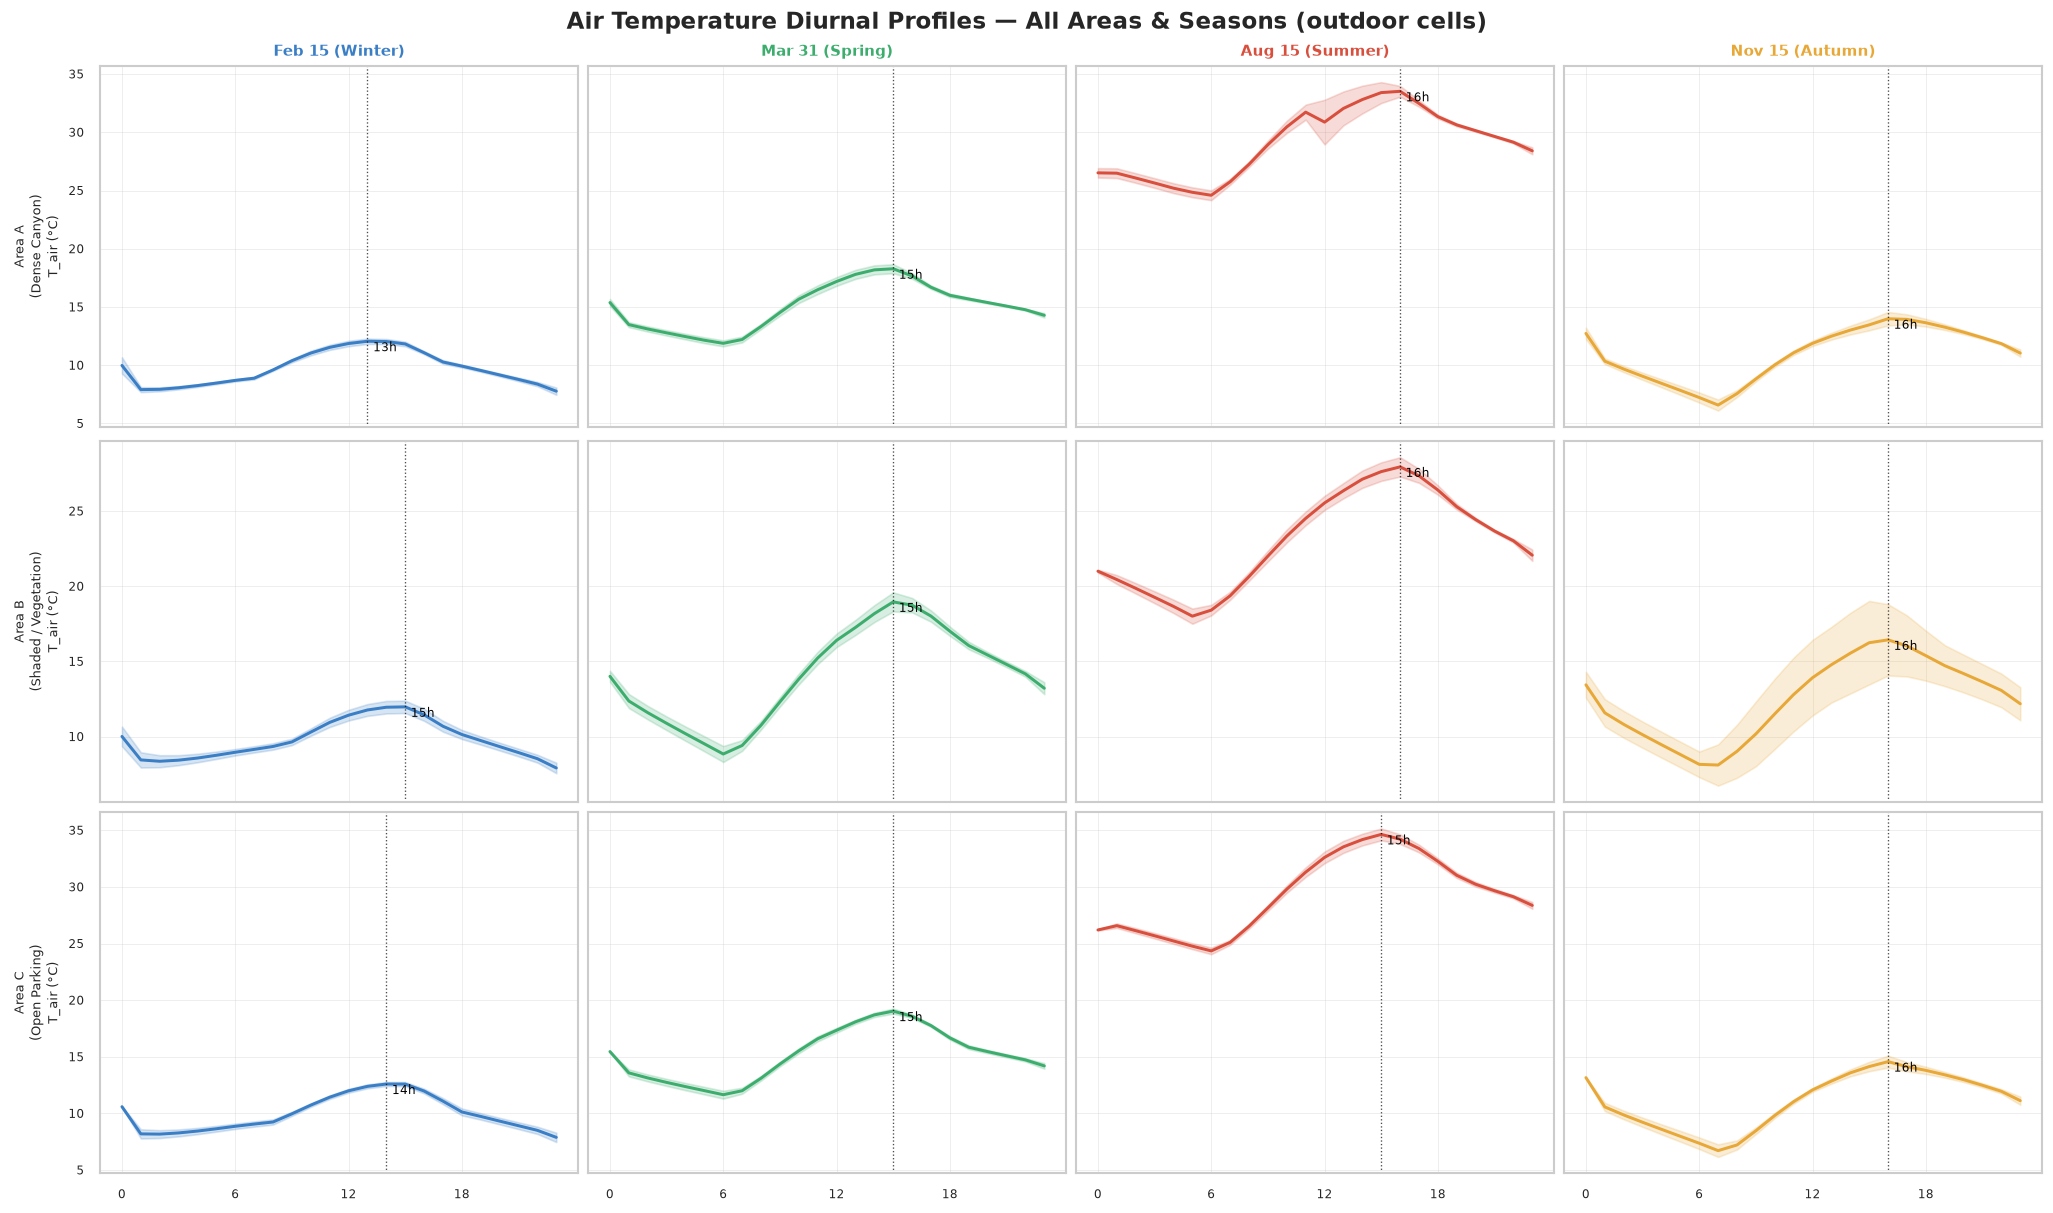

Saved B4


In [6]:
fig, axes = plt.subplots(len(AREA_ORDER), len(DATE_ORDER), figsize=(17, 10),
                         sharey='row', sharex=True, constrained_layout=True)
fig.suptitle('Air Temperature Diurnal Profiles — All Areas & Seasons (outdoor cells)',
             fontsize=14, fontweight='bold')

for r, area in enumerate(AREA_ORDER):
    for c, date in enumerate(DATE_ORDER):
        ax = axes[r, c]
        if r == 0: ax.set_title(DATE_LABELS[date], fontsize=9, fontweight='bold', color=DATE_COLORS[date])
        if c == 0: ax.set_ylabel(AREA_LABELS[area] + '\nT_air (°C)', fontsize=8)
        sub = atm[(atm['area'] == area) & (atm['date'] == date)]
        if len(sub) == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes, color='grey')
            continue
        hrs = sorted(sub['hour'].unique())
        grp = sub.groupby('hour')[AIR_TEMP_COL]
        mn, sd = grp.mean().reindex(hrs), grp.std().reindex(hrs)
        color = DATE_COLORS[date]
        ax.plot(hrs, mn, color=color, lw=1.8)
        ax.fill_between(hrs, mn - sd, mn + sd, color=color, alpha=0.2)
        peak_h = mn.idxmax()
        ax.axvline(peak_h, color='black', lw=0.8, ls=':', alpha=0.7)
        ax.text(peak_h + 0.3, mn.max(), f'{peak_h}h', fontsize=7, va='top', color='black')
        ax.set_xticks(range(0, 24, 6))
        ax.tick_params(labelsize=7)
        ax.grid(lw=0.4, alpha=0.5)

fig.savefig(SAVE_DIR / 'B4_air_diurnal_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved B4')

## B5 — Peak hour summary table

In [7]:
rows = []
for area in AREA_ORDER:
    for date in DATE_ORDER:
        for label, df, col in [('air', atm, AIR_TEMP_COL), ('surface', srf, SURF_TEMP_COL)]:
            sub = df[(df['area'] == area) & (df['date'] == date)]
            if len(sub) == 0: continue
            grp = sub.groupby('hour')[col].mean()
            peak_h = int(grp.idxmax())
            peak_t = round(grp.max(), 2)
            rows.append({'Area': area, 'Date': date, 'Type': label,
                         'Peak hour': peak_h, 'Peak T (°C)': peak_t})

peak_df = pd.DataFrame(rows)
print(peak_df.to_string(index=False))
print('\nAll done. Figures saved to:', SAVE_DIR)

      Area  Date    Type  Peak hour  Peak T (°C)
Zefkseidos 15Feb     air         13    12.060000
Zefkseidos 15Feb surface         12    15.730000
Zefkseidos 31Mar     air         15    18.280001
Zefkseidos 31Mar surface         13    24.680000
Zefkseidos 15Aug     air         16    33.509998
Zefkseidos 15Aug surface         11    40.439999
Zefkseidos 15Nov     air         16    13.990000
Zefkseidos 15Nov surface          0    15.110000
    Shaded 15Feb     air         15    11.980000
    Shaded 15Feb surface          0    16.250000
    Shaded 31Mar     air         15    18.959999
    Shaded 31Mar surface         15    23.900000
    Shaded 15Aug     air         16    27.940001
    Shaded 15Aug surface         14    34.759998
    Shaded 15Nov     air         16    16.430000
    Shaded 15Nov surface          0    16.930000
Waterfront 15Feb     air         14    12.590000
Waterfront 15Feb surface         14    16.760000
Waterfront 31Mar     air         15    19.030001
Waterfront 31Mar sur